In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Створюємо дані
data = {
    'item': ['Latte', 'Cappuccino', 'Latte', 'Tea', 'Espresso', 'Cappuccino', 'Latte', 'Tea', 'Cake', 'Cake'],
    'category': ['Drink', 'Drink', 'Drink', 'Drink', 'Drink', 'Drink', 'Drink', 'Drink', 'Food', 'Food'],
    'price': [50, 45, 50, 30, 35, 45, 50, 30, 80, 80],
    'quantity': [5, 12, np.nan, 8, 15, np.nan, 7, 10, 4, 6],
    'date': pd.to_datetime(['2026-04-01', '2026-04-01', '2026-04-02', '2026-04-02', '2026-04-03', '2026-04-03', '2026-04-04', '2026-04-04', '2026-04-05', '2026-04-05'])
}

df = pd.DataFrame(data)



In [41]:
df.head


<bound method NDFrame.head of          item category  price  quantity       date
0       Latte    Drink     50       5.0 2026-04-01
1  Cappuccino    Drink     45      12.0 2026-04-01
2       Latte    Drink     50       NaN 2026-04-02
3         Tea    Drink     30       8.0 2026-04-02
4    Espresso    Drink     35      15.0 2026-04-03
5  Cappuccino    Drink     45       NaN 2026-04-03
6       Latte    Drink     50       7.0 2026-04-04
7         Tea    Drink     30      10.0 2026-04-04
8        Cake     Food     80       4.0 2026-04-05
9        Cake     Food     80       6.0 2026-04-05>

In [42]:
df.shape

(10, 5)

In [56]:

df.columns
mask = df['quantity'].notna() 
mask[mask == True].count()
median = np.nanmedian(df['quantity'])
df['quantity'] = df['quantity'].fillna(median)

In [57]:
df['total_sales'] = df['quantity'] * df['price']

In [65]:

item_sales = df.groupby('item')['total_sales'].sum().reset_index()

In [66]:
item_sales

,item,total_sales
0,Cake,800.0
1,Cappuccino,877.5
2,Espresso,525.0
3,Latte,975.0
4,Tea,540.0


In [67]:
plt.figure(figsize =(12,6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

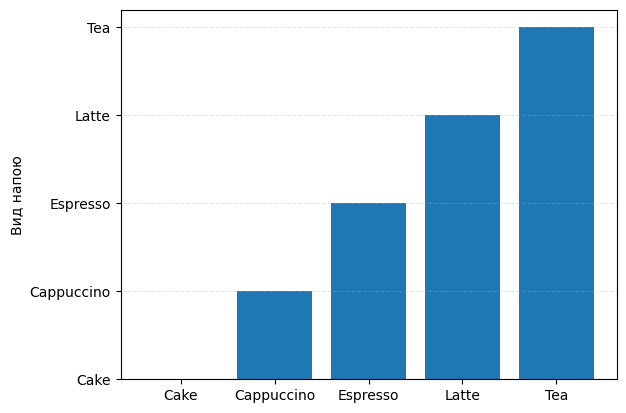

In [72]:
plt.bar(item_sales['item'],item_sales['item'])
plt.ylabel('Вид напою')
plt.grid(axis='y', linestyle='--',alpha=0.3)

In [73]:
daily_ravenue = df.groupby('date')['total_sales'].sum().reset_index()

(array([20544. , 20544.5, 20545. , 20545.5, 20546. , 20546.5, 20547. ,
        20547.5, 20548. ]),
 [Text(20544.0, 0, '04-01 00'),
  Text(20544.5, 0, '04-01 12'),
  Text(20545.0, 0, '04-02 00'),
  Text(20545.5, 0, '04-02 12'),
  Text(20546.0, 0, '04-03 00'),
  Text(20546.5, 0, '04-03 12'),
  Text(20547.0, 0, '04-04 00'),
  Text(20547.5, 0, '04-04 12'),
  Text(20548.0, 0, '04-05 00')])

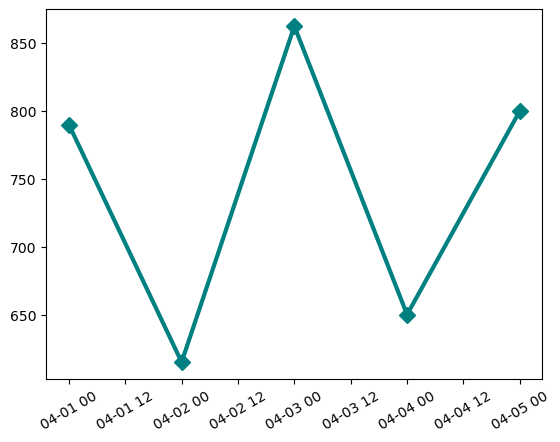

In [77]:
plt.plot(daily_ravenue['date'], daily_ravenue['total_sales'], 
         marker='D', linestyle='-', color='teal', linewidth=3, markersize=8)
plt.xticks(rotation=30)

In [82]:
date_rev_drink = df[df['category'] == 'Drink'].groupby('date')['quantity'].sum().reset_index() 


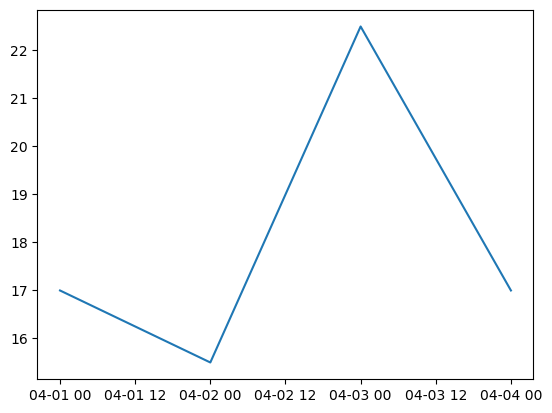

In [84]:
plt.plot(date_rev_drink['date'],date_rev_drink['quantity'])